# Aim:

### To explore daily minimum temperature time series (1981–1990) through visualization and statistical analysis, identify key temporal patterns (trend, seasonality, autocorrelation), examine distribution & variability, and model short-term dependencies using simple AR, MA, and ARMA approaches.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import lag_plot
import numpy as np

In [3]:
df = pd.read_csv('daily-min-temperatures.csv', parse_dates=['Date'], index_col='Date')

In [4]:
print(df.head())

            Temp
Date            
1981-01-01  20.7
1981-01-02  17.9
1981-01-03  18.8
1981-01-04  14.6
1981-01-05  15.8


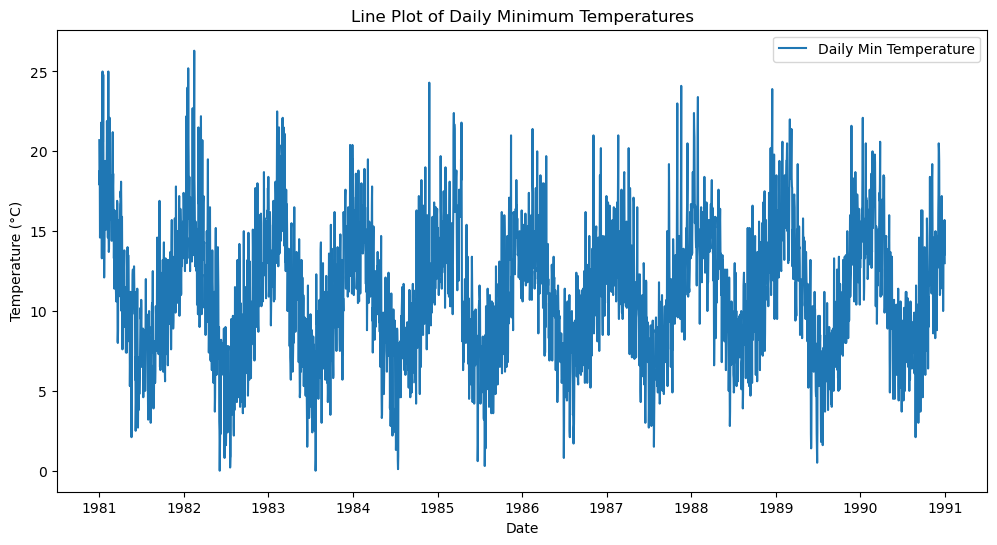

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df['Temp'], label='Daily Min Temperature')
plt.title('Line Plot of Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

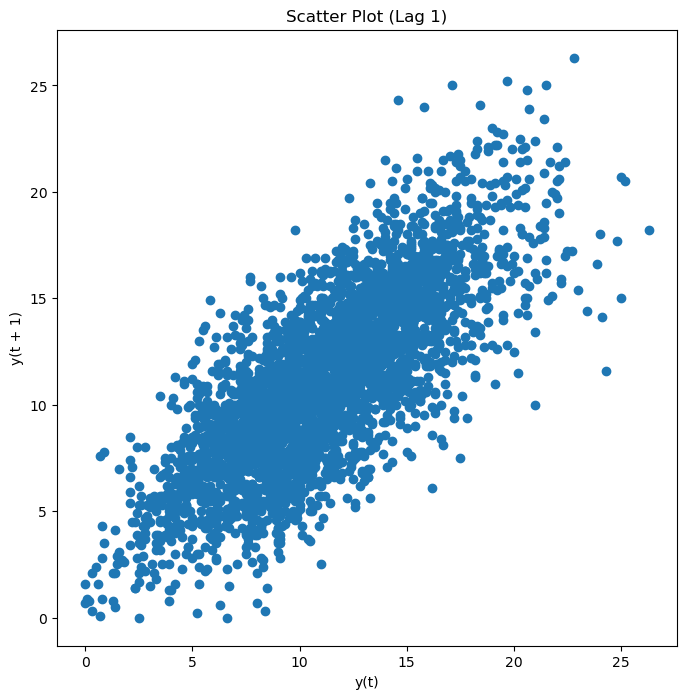

In [6]:
plt.figure(figsize=(8, 8))
lag_plot(df['Temp'], lag=1)
plt.title('Scatter Plot (Lag 1)')
plt.show()

<Figure size 1200x600 with 0 Axes>

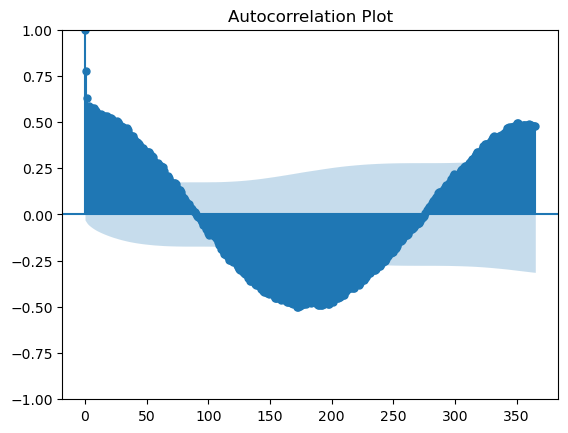

In [7]:
plt.figure(figsize=(12, 6))
plot_acf(df['Temp'], lags=365)  # Lags up to a year for seasonality
plt.title('Autocorrelation Plot')
plt.show()

<Figure size 1200x600 with 0 Axes>

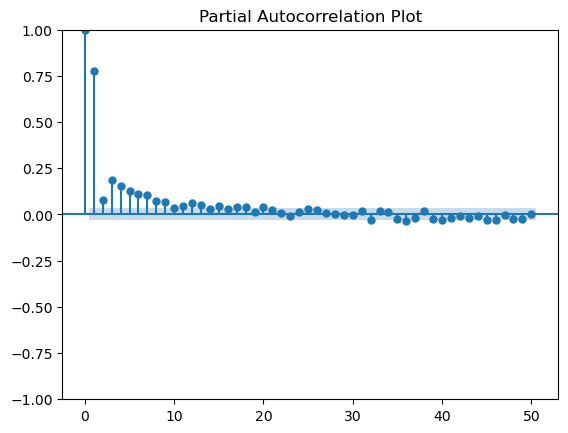

In [9]:
plt.figure(figsize=(12, 6))
plot_pacf(df['Temp'], lags=50)
plt.title('Partial Autocorrelation Plot')
plt.show()

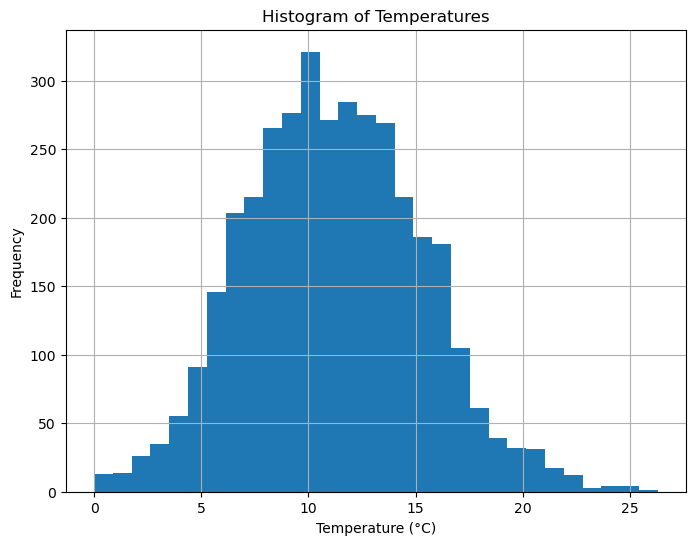

In [10]:
plt.figure(figsize=(8, 6))
df['Temp'].hist(bins=30)
plt.title('Histogram of Temperatures')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

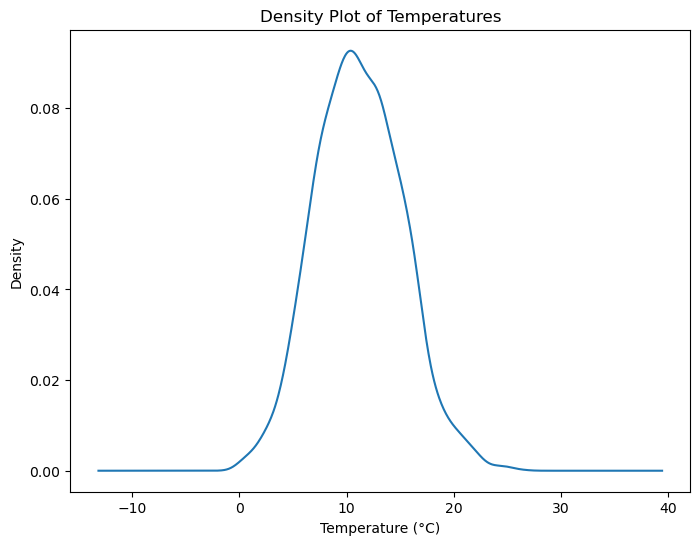

In [11]:
plt.figure(figsize=(8, 6))
df['Temp'].plot(kind='kde')
plt.title('Density Plot of Temperatures')
plt.xlabel('Temperature (°C)')
plt.show()

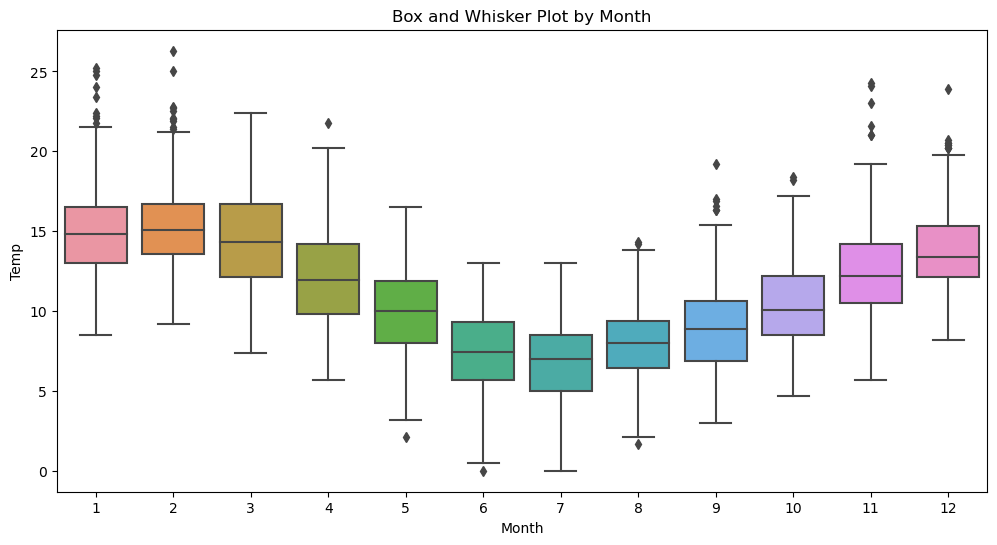

In [13]:
df['Month'] = df.index.month
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Temp', data=df)
plt.title('Box and Whisker Plot by Month')
plt.show()

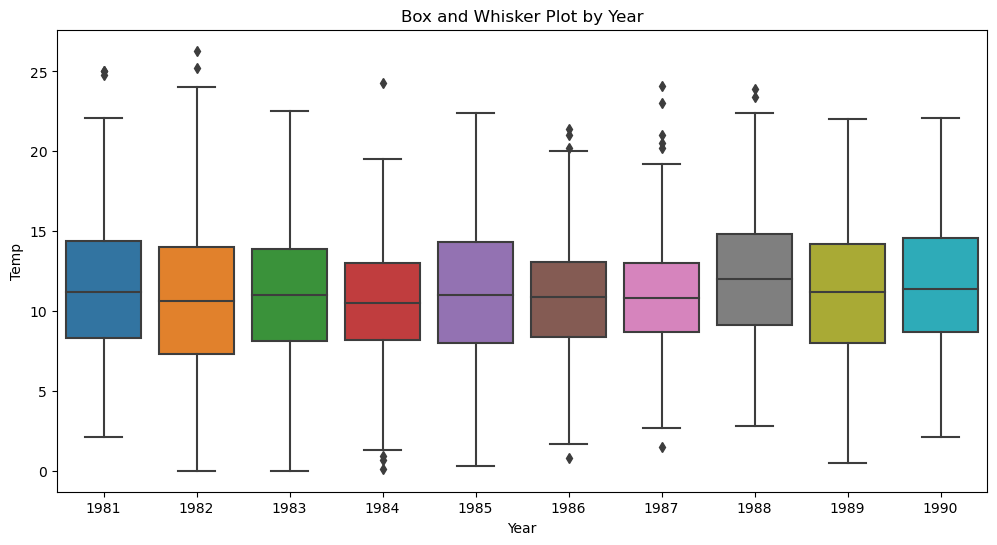

In [14]:
df['Year'] = df.index.year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Temp', data=df)
plt.title('Box and Whisker Plot by Year')
plt.show()

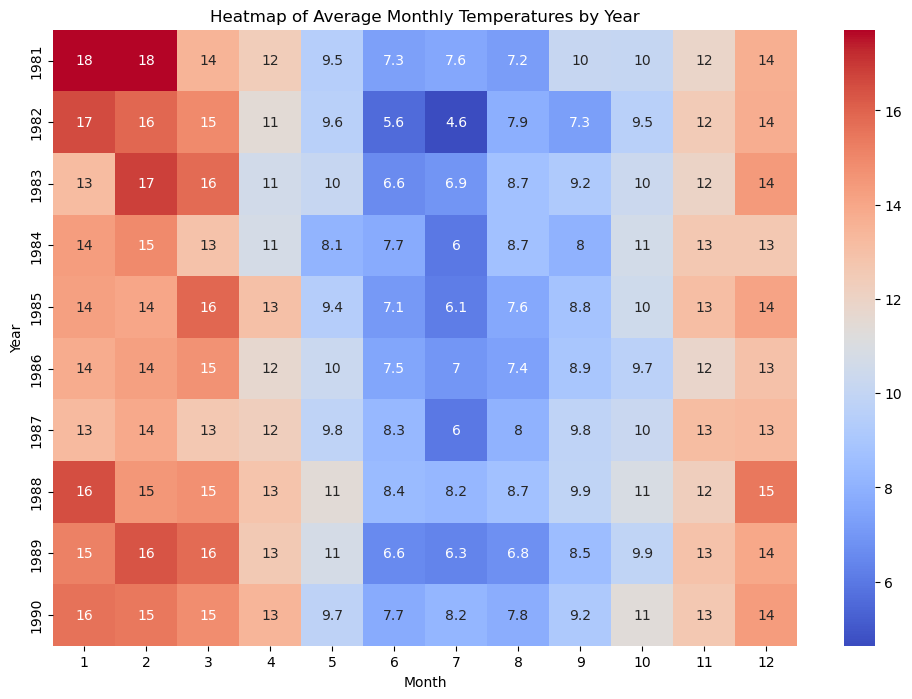

In [15]:
pivot = df.pivot_table(values='Temp', index='Year', columns='Month', aggfunc=np.mean)
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Heatmap of Average Monthly Temperatures by Year')
plt.show()

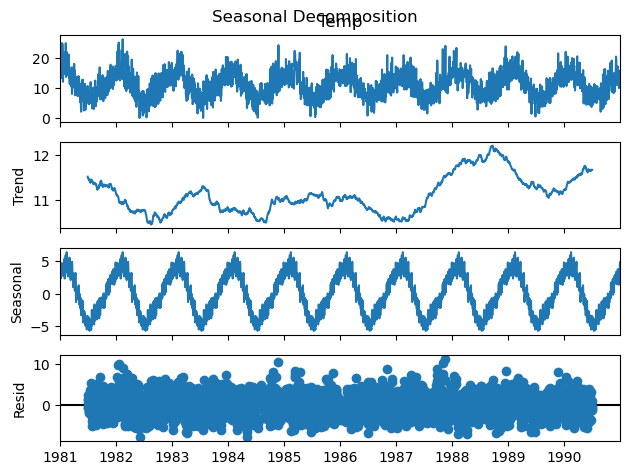

In [16]:
decompose = seasonal_decompose(df['Temp'], model='additive', period=365)  # Yearly seasonality
decompose.plot()
plt.suptitle('Seasonal Decomposition')
plt.show()

In [17]:
ar_model = ARIMA(df['Temp'], order=(2, 0, 0)).fit()
print('AR Model Summary:')
print(ar_model.summary())

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


AR Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -8618.979
Date:                Fri, 30 Jan 2026   AIC                          17245.958
Time:                        17:02:53   BIC                          17270.767
Sample:                             0   HQIC                         17254.793
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1908      0.207     53.962      0.000      10.784      11.597
ar.L1          0.7155      0.015     47.484      0.000       0.686       0.745
ar.L2          0.0772      0.016  

In [18]:
ma_model = ARIMA(df['Temp'], order=(0, 0, 2)).fit()
print('MA Model Summary:')
print(ma_model.summary())

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


MA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -8969.888
Date:                Fri, 30 Jan 2026   AIC                          17947.777
Time:                        17:02:59   BIC                          17972.587
Sample:                             0   HQIC                         17956.612
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1785      0.100    112.065      0.000      10.983      11.374
ma.L1          0.7608      0.015     51.298      0.000       0.732       0.790
ma.L2          0.3553      0.015  

In [19]:
arma_model = ARIMA(df['Temp'], order=(2, 0, 2)).fit()
print('ARMA Model Summary:')
print(arma_model.summary())

C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive pa

ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   Temp   No. Observations:                 3650
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -8384.568
Date:                Fri, 30 Jan 2026   AIC                          16781.136
Time:                        17:03:07   BIC                          16818.351
Sample:                             0   HQIC                         16794.389
                               - 3650                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.4839      0.812     14.147      0.000       9.893      13.075
ar.L1          1.2365      0.040     30.766      0.000       1.158       1.315
ar.L2         -0.2421      0.040

# Result:
###  The daily minimum temperature series (1981–1990) shows strong annual seasonality, with minimums averaging 15–18 °C in December–February and 5–8 °C in June–August. Short-term persistence is evident from lag-1 autocorrelation of ~0.6–0.7, while ACF confirms clear yearly cycles (~365-day spikes). Temperatures are roughly normally distributed around 11–12 °C with mild left skew and no obvious long-term trend over the decade. A simple ARMA(2,2) model best captured the short-term dependencies among those tested.